In [85]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from simulate_population import sim_population
from Class_definitions import (
    prepare_data_for_multicox, train_coxmulti, MultiCoxNN,
    prepare_data_for_multibinary, train_binmulti, MultiDiscreteTimeNN
)

In [144]:
# ============================================================================
# HYPERPARAMETERS (matching Simple_Cox_with_NN-Copy1)
# ============================================================================
BATCH_SIZE = 512
EPOCHS = 300
HIDDEN_LAYERS_COX = (16, 16)
HIDDEN_LAYERS_MULTIBINARY = (32, 32)
STEP_FORWARD = 2
N_STEPS = 5
N_INTERVALS = 50
COVARIATE_COLS = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
EVENT_TYPES = ["a", "b", "c", "d", "e"]



In [146]:
# ============================================================================
# PART A: Generate Data
# ============================================================================
print("=" * 80)
print("PART A: Generating Simulation Data")
print("=" * 80)
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Generate population with 5 steps forward, step_forward=2
population = sim_population(N=20000, step_forward=STEP_FORWARD, randomseed=42+15)
for i in range(N_STEPS):
    population.step()
    print(f"Step {i+1}/{N_STEPS} completed")

# Get Cox format data (train/test split)
df_cox = population.to_cox_format()
print(f"\nCox format data shape: {df_cox.shape}")
print(f"Columns: {df_cox.columns.tolist()[:15]}...")

# 80/20 train/test split
n_train = int(0.8 * len(df_cox))
df_short = df_cox.iloc[:n_train].reset_index(drop=True)
df_test = df_cox.iloc[n_train:].reset_index(drop=True)

print(f"\nTrain set: {len(df_short)} samples")
print(f"Test set: {len(df_test)} samples")

PART A: Generating Simulation Data
Step 1/5 completed
Step 2/5 completed
Step 3/5 completed
Step 4/5 completed
Step 5/5 completed

Cox format data shape: (20000, 18)
Columns: ['id', 'age_start', 'bmi', 'hyp', 'smoke', 'sex', 'eth1', 'eth2', 'event_a', 'time_a', 'event_b', 'time_b', 'event_c', 'time_c', 'event_d']...

Train set: 16000 samples
Test set: 4000 samples


In [132]:
# ============================================================================
# PART B & C: Initialize & Train Models
# ============================================================================
print("\n" + "=" * 80)
print("PART B & C: Training Models")
print("=" * 80)

models = {}
cindex_results = {}

# -------- 1. Lifelines Cox (Baseline) --------
print("\n[1/5] Training Lifelines Cox Model...")
models['lifelines_cox'] = {}
for event in EVENT_TYPES:
    print(f"  → Event {event}...", end=" ")
    cph = CoxPHFitter()
    time_col = f"time_{event}"
    event_col = f"event_{event}"
    cph.fit(df_short[[time_col, event_col] + COVARIATE_COLS], 
            duration_col=time_col, event_col=event_col)
    models['lifelines_cox'][event] = cph
    print("done")

# -------- 2. Multi-Outcome Cox (NO Hidden Layers) --------
print("\n[2/5] Training Multi-Outcome Cox (No Hidden Layers)...")
x2_train, time2_train, event2_train = prepare_data_for_multicox(
    df_short, 
    covariate_cols=COVARIATE_COLS,
    time_cols=[f"time_{e}" for e in EVENT_TYPES],
    event_cols=[f"event_{e}" for e in EVENT_TYPES]
)
models['multicox_no_hidden'] = train_coxmulti(
    x2_train, time2_train, event2_train, 
    hidden_dims=(), epochs=EPOCHS, K=5
)
print("done")

# -------- 3. Multi-Outcome Cox (WITH Hidden Layers) --------
print("\n[3/5] Training Multi-Outcome Cox (With Hidden Layers)...")
models['multicox_with_hidden'] = train_coxmulti(
    x2_train, time2_train, event2_train, 
    hidden_dims=HIDDEN_LAYERS_COX, epochs=EPOCHS, K=5
)
print("done")

# -------- 4. Multi-Binary (NO Hidden Layers) --------
print("\n[4/5] Training Multi-Binary Model (No Hidden Layers)...")
X_train, intervals_train, events_train, n_intervals = prepare_data_for_multibinary(
    df_short, 
    features=COVARIATE_COLS,
    event_types=EVENT_TYPES,
    n_intervals=N_INTERVALS,
    even_split=True  # Use time split every 2 years
)
models['multibinary_no_hidden'] = train_binmulti(
    X_train, intervals_train, events_train, n_intervals,
    hidden_dims=(), lr=0.01, epochs=EPOCHS, batch_size=BATCH_SIZE
)
print("done")

# -------- 5. Multi-Binary (WITH Hidden Layers) --------
print("\n[5/5] Training Multi-Binary Model (With Hidden Layers)...")
models['multibinary_with_hidden'] = train_binmulti(
    X_train, intervals_train, events_train, n_intervals,
    hidden_dims=HIDDEN_LAYERS_MULTIBINARY, lr=0.001, epochs=EPOCHS+100, batch_size=BATCH_SIZE*2
)
print("done")


PART B & C: Training Models

[1/5] Training Lifelines Cox Model...
  → Event a... done
  → Event b... done
  → Event c... done
  → Event d... done
  → Event e... done

[2/5] Training Multi-Outcome Cox (No Hidden Layers)...
Epoch 0, loss = 104308.2891
Epoch 50, loss = 79412.8359
Epoch 100, loss = 79156.5781
Epoch 150, loss = 79073.3359
Epoch 200, loss = 79029.8750
Epoch 250, loss = 79009.6250
Epoch 299, loss = 79002.3125
done

[3/5] Training Multi-Outcome Cox (With Hidden Layers)...
Epoch 0, loss = 80261.6953
Epoch 50, loss = 79162.7188
Epoch 100, loss = 78606.7344
Epoch 150, loss = 78377.8594
Epoch 200, loss = 78356.6719
Epoch 250, loss = 78350.5469
Epoch 299, loss = 78347.3516
done

[4/5] Training Multi-Binary Model (No Hidden Layers)...
Epoch 1/300, Loss: 1.9775
Epoch 51/300, Loss: 0.0193
Epoch 101/300, Loss: 0.0149
Epoch 151/300, Loss: 0.0142
Epoch 201/300, Loss: 0.0140
Epoch 251/300, Loss: 0.0139
Epoch 300/300, Loss: 0.0139
done

[5/5] Training Multi-Binary Model (With Hidden Laye

In [156]:
# ============================================================================
# PART D: Extract Beta Coefficients
# ============================================================================
print("\n" + "=" * 80)
print("PART D: Extracting Beta Coefficients")
print("=" * 80)

beta_df_list = []

# Lifelines Cox - extract coefficients
print("\nExtracting coefficients from Lifelines Cox...")
for event in EVENT_TYPES:
    cph = models['lifelines_cox'][event]
    for covariate in COVARIATE_COLS:
        beta_df_list.append({
            'Model': 'Lifelines Cox',
            'Event': event,
            'Covariate': covariate,
            'Beta': cph.params_[covariate]
        })

# Multi-Outcome Cox (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Multi-Outcome Cox (No Hidden Layers)...")
model_multicox_no_hidden = models['multicox_no_hidden']
with torch.no_grad():
    # The final linear layer maps to K outcomes
    final_layer_weight = model_multicox_no_hidden.net[-1].weight  # (K, p)
    for k, event in enumerate(EVENT_TYPES):
        for i, covariate in enumerate(COVARIATE_COLS):
            beta_df_list.append({
                'Model': 'MultiCox No Hidden',
                'Event': event,
                'Covariate': covariate,
                'Beta': final_layer_weight[k, i].item()
            })

# Multi-Binary (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Multi-Binary (No Hidden Layers)...")
model_multibinary_no_hidden = models['multibinary_no_hidden']
with torch.no_grad():
    # The final linear layer maps to K outcomes
    final_layer_weight = model_multibinary_no_hidden.net[-1].weight  # (K, p)
    for k, event in enumerate(EVENT_TYPES):
        for i, covariate in enumerate(COVARIATE_COLS):
            beta_df_list.append({
                'Model': 'MultiBinary No Hidden',
                'Event': event,
                'Covariate': covariate,
                'Beta': final_layer_weight[k, i].item()
            })

beta_comparison_df = pd.DataFrame(beta_df_list)
print(f"\nTotal coefficients extracted: {len(beta_comparison_df)}")




PART D: Extracting Beta Coefficients

Extracting coefficients from Lifelines Cox...
Extracting coefficients from Multi-Outcome Cox (No Hidden Layers)...
Extracting coefficients from Multi-Binary (No Hidden Layers)...

Total coefficients extracted: 105


In [158]:
# ============================================================================
# PART E: Compute C-Index for All Models
# ============================================================================
print("\n" + "=" * 80)
print("PART E: Computing C-Index for All Models")
print("=" * 80)
cindex_df_list = []

# Prepare test data
x2_test, time2_test, event2_test = prepare_data_for_multicox(
    df_test, 
    covariate_cols=COVARIATE_COLS,  time_cols=[f"time_{e}" for e in EVENT_TYPES], 
    event_cols=[f"event_{e}" for e in EVENT_TYPES])
X_test, intervals_test, events_test, _ = prepare_data_for_multibinary(
    df_test,
    features=COVARIATE_COLS,  event_types=EVENT_TYPES,  n_intervals=N_INTERVALS,  even_split=True)

# -------- 1. Lifelines Cox C-Index --------
print("\nComputing C-Index for Lifelines Cox...")
for event in EVENT_TYPES:
    cph = models['lifelines_cox'][event]
    time_col = f"time_{event}"
    event_col = f"event_{event}"
    predictions = cph.predict_partial_hazard(df_test[COVARIATE_COLS])
    c_index = concordance_index(df_test[time_col].values, 1- predictions.values,df_test[event_col].values)
    cindex_df_list.append({'Model': 'Lifelines Cox','Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 2. Multi-Outcome Cox (No Hidden Layers) C-Index --------
print("\nComputing C-Index for Multi-Outcome Cox (No Hidden Layers)...")
with torch.no_grad(): eta_test = models['multicox_no_hidden'](x2_test)
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index(df_test[f"time_{event}"].values,-eta_test[:, k].numpy(), df_test[f"event_{event}"].values)
    cindex_df_list.append({ 'Model': 'MultiCox No Hidden',  'Event': event, 'C-Index': c_index })
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 3. Multi-Outcome Cox (With Hidden Layers) C-Index --------
print("\nComputing C-Index for Multi-Outcome Cox (With Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multicox_with_hidden'](x2_test)
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index(df_test[f"time_{event}"].values, -eta_test[:, k].numpy(), df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'MultiCox With Hidden', 'Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 4. Multi-Binary (No Hidden Layers) C-Index --------
print("\nComputing C-Index for Multi-Binary (No Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multibinary_no_hidden'].get_eta(torch.FloatTensor(X_test)).numpy()
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index( df_test[f"time_{event}"].values,-eta_test[:, k], df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'MultiBinary No Hidden', 'Event': event, 'C-Index': c_index })
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 5. Multi-Binary (With Hidden Layers) C-Index --------
print("\nComputing C-Index for Multi-Binary (With Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multibinary_with_hidden'].get_eta(torch.FloatTensor(X_test)).numpy()
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index( df_test[f"time_{event}"].values, -eta_test[:, k], df_test[f"event_{event}"].values)
    cindex_df_list.append({ 'Model': 'MultiBinary With Hidden','Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

cindex_df = pd.DataFrame(cindex_df_list)

# Reshape beta_comparison_df to have Model as columns, with Event as an additional column
beta_comparison_df = beta_comparison_df.pivot_table(   index=['Event', 'Covariate'],    columns='Model',    values='Beta').reset_index()



PART E: Computing C-Index for All Models

Computing C-Index for Lifelines Cox...
  Event a: C-Index = 0.7168
  Event b: C-Index = 0.6446
  Event c: C-Index = 0.6354
  Event d: C-Index = 0.6070
  Event e: C-Index = 0.6271

Computing C-Index for Multi-Outcome Cox (No Hidden Layers)...
  Event a: C-Index = 0.7166
  Event b: C-Index = 0.6446
  Event c: C-Index = 0.6354
  Event d: C-Index = 0.6070
  Event e: C-Index = 0.6271

Computing C-Index for Multi-Outcome Cox (With Hidden Layers)...
  Event a: C-Index = 0.7168
  Event b: C-Index = 0.7071
  Event c: C-Index = 0.7014
  Event d: C-Index = 0.6052
  Event e: C-Index = 0.6251

Computing C-Index for Multi-Binary (No Hidden Layers)...
  Event a: C-Index = 0.7065
  Event b: C-Index = 0.6352
  Event c: C-Index = 0.5293
  Event d: C-Index = 0.5888
  Event e: C-Index = 0.6154

Computing C-Index for Multi-Binary (With Hidden Layers)...
  Event a: C-Index = 0.7157
  Event b: C-Index = 0.7106
  Event c: C-Index = 0.7071
  Event d: C-Index = 0.6152


In [160]:
# ============================================================================
# SUMMARY RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY RESULTS")
print("=" * 80)
print("### C-Index Comparison by Event ###")
cindex_pivot = cindex_df.pivot(index='Model', columns='Event', values='C-Index').round(4).T
cindex_pivot

#print("\n### Mean C-Index by Model ###")
#print(cindex_df.groupby('Model')['C-Index'].mean().round(4).sort_values(ascending=False))

# Save results to CSV
#print("\n" + "=" * 80)
#print("Saving Results to CSV...")
#print("=" * 80)
#beta_comparison_df.to_csv('beta_coefficients_comparison.csv', index=False)
#cindex_df.to_csv('cindex_comparison.csv', index=False)
#cindex_pivot.to_csv('cindex_pivot.csv')
#print("✓ Results saved!")


SUMMARY RESULTS
### C-Index Comparison by Event ###


Model,Lifelines Cox,MultiBinary No Hidden,MultiBinary With Hidden,MultiCox No Hidden,MultiCox With Hidden
Event,,,,,
a,0.7168,0.7065,0.7157,0.7166,0.7168
b,0.6446,0.6352,0.7106,0.6446,0.7071
c,0.6354,0.5293,0.7071,0.6354,0.7014
d,0.6070,0.5888,0.6152,0.6070,0.6052
e,0.6271,0.6154,0.6243,0.6271,0.6251


In [162]:
beta_comparison_df.loc[beta_comparison_df.Event=="a", ]

Model,Event,Covariate,Lifelines Cox,MultiBinary No Hidden,MultiCox No Hidden
0,a,age_start,0.028462,0.065068,0.028037
1,a,bmi,0.488395,0.771348,0.480853
2,a,eth1,0.548445,1.006248,0.518107
3,a,eth2,2.038634,2.285600,1.880830
4,a,hyp,0.726445,1.217710,0.714124
5,a,sex,-0.005565,0.042523,-0.006754
6,a,smoke,0.008961,-0.301262,0.007624


<Axes: xlabel='Event'>

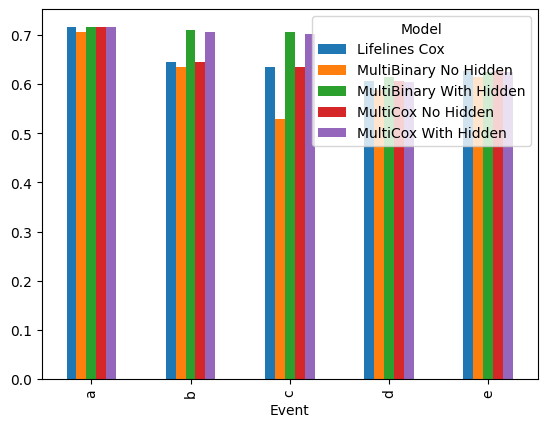

In [164]:
cindex_pivot.T.plot.bar()
